# 8. Fractals: Infinite Detail

One line of mathematics, iterated without mercy, produces an object with infinite detail at every scale. Today we compute the Mandelbrot set, learn to zoom into it, and meet the strange episode in which fractal geometry was asked to authenticate Jackson Pollock.

## Today's destination

A detail from the *seahorse valley*, the crevice between the two largest lobes of the Mandelbrot set, rendered at print resolution. Every curl in this image contains further curls that the resolution cannot show; by the end of today you can navigate to any of them and render your own.

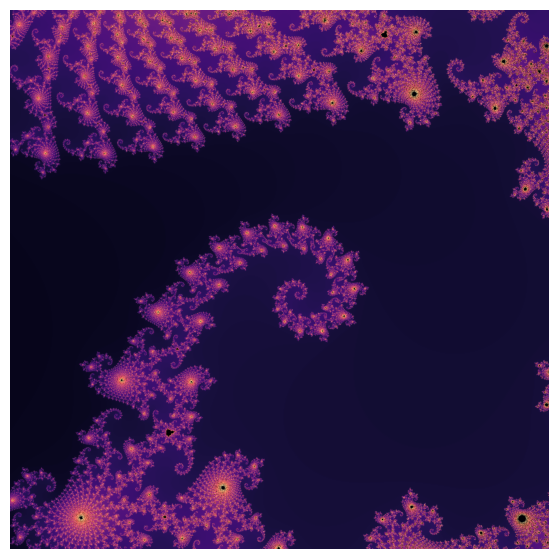

In [1]:
# display this chapter's showpiece (generated by the last cell of this notebook)
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

showpiece_path = "../assets/outputs/ch08_showpiece.png"
if os.path.exists(showpiece_path):
    image = mpimg.imread(showpiece_path)
    plt.figure(figsize=(10, 7))
    plt.imshow(image)
    plt.axis("off")
    plt.show()
else:
    print("Not generated yet -- run the whole notebook once and come back.")

## Context: the geometry of roughness, and the Pollock affair

Classical geometry is a geometry of smoothness: lines, circles, cones. **Benoît Mandelbrot** (1924-2010) spent his career on everything it left out: coastlines, clouds, cotton prices, noise in telephone lines. His claim, summed up in *The Fractal Geometry of Nature* (1982), was that roughness has its own geometry, built on **self-similarity** (Selbstähnlichkeit): the parts resemble the whole, at scale after scale. (You met one such object already: chapter 7's Koch curve, self-similar by construction.) He coined the word *fractal* in 1975. The set that carries his name was first plotted in crude printer graphics in the late 1970s, and when the touring Goethe-Institut exhibition *Frontiers of Chaos* (from 1985) and the book that grew from it, Peitgen and Richter's *The Beauty of Fractals* (1986), brought high-resolution renderings to a wide public, something unusual happened: images straight out of a mathematics department were received, debated, and hung as art. Whether they *are* art is a genuinely contested question; Mandelbrot himself enjoyed pointing to precedents in painting, Hokusai's *Great Wave* (c. 1830-32) above all, where the foam of the large wave breaks into small waves shaped like the large one.

Art history has one famous, cautionary encounter with fractals. In 1999 the physicist **Richard Taylor** and colleagues published a short paper in *Nature* claiming that Jackson Pollock's drip paintings show fractal structure, that their fractal dimension rose steadily over Pollock's career, and, by implication, that a number could distinguish real Pollocks from fakes. The claim traveled far: the Pollock-Krasner Foundation consulted fractal analysis when a cache of disputed paintings surfaced in the 2000s. Then came the pushback. In 2006, **Katherine Jones-Smith and Harsh Mathur** showed that trivial hand-drawn doodles pass the same fractal tests, and argued that the range of scales in a Pollock canvas is far too narrow to establish fractality at all; Taylor's group replied; the dispute ran on in the physics literature. The episode matters for this course beyond gossip: it is what it looks like when a computational method meets connoisseurship, with attribution and money at stake, and the method's assumptions suddenly matter enormously. Keep it in mind whenever a number claims to capture an artwork; we will be generating such numbers ourselves in the chapters ahead.

Today stays on the constructive side of that story: we build the most famous fractal of all, and the tool for it is the complex plane.

## Complex numbers are points

A **complex number** (komplexe Zahl) $z = a + bi$ is nothing more exotic than a point: $a$ steps east, $b$ steps north, with $i$ defined by $i^2 = -1$. The plane of all such points is the complex plane, and Python has complex numbers built in: `2 + 1j` (engineers' notation, `j` instead of $i$).

The payoff of the odd rule $i^2 = -1$ is geometric: **multiplying complex numbers rotates and scales**. Multiply any $z$ by itself and its distance from zero squares while its angle doubles. Watch what repeated squaring does to a point that starts just outside the unit circle versus just inside:

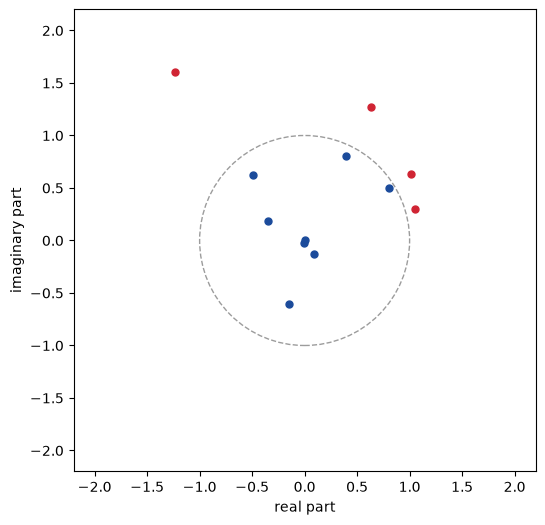

In [2]:
# repeated squaring: outside the unit circle points flee, inside they fall in
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 6))
circle = plt.Circle((0, 0), 1, fill=False, color="#9C9C9C", linestyle="--")
ax.add_patch(circle)
for start, color in [(1.05 + 0.3j, "#D02433"), (0.8 + 0.5j, "#1B4B9B")]:
    z = start
    for step in range(8):
        ax.plot(z.real, z.imag, "o", color=color, markersize=5)
        z = z * z                       # square: angle doubles, radius squares
ax.set_xlim(-2.2, 2.2)
ax.set_ylim(-2.2, 2.2)
ax.set_aspect("equal")
ax.set_xlabel("real part")
ax.set_ylabel("imaginary part")
plt.show()

The red orbit (start radius 1.09) spirals outward and is soon gone; the blue one (radius 0.94) spirals into zero. The unit circle is the watershed. The Mandelbrot iteration complicates this game by exactly one term:

$$z_{\text{next}} = z^2 + c$$

Start at $z = 0$, square, add the constant $c$, repeat. For some values of $c$ the orbit stays bounded forever; for others it escapes to infinity. The **Mandelbrot set** is simply the collection of all $c$ whose orbit never escapes. There is a clean test for escaping: once $|z| > 2$ (the bars mean "distance from zero"), no return is possible (squaring then outruns any $c$ we started from). Iterate by hand for two values of $c$ and watch both fates:

In [3]:
# two orbits by hand: c = -1 settles into a cycle, c = 0.3 slowly escapes
for c in [-1.0, 0.3]:
    z = 0
    print(f"c = {c}:")
    for step in range(14):
        z = z * z + c
        marker = "  <-- past radius 2, gone forever" if abs(z) > 2 else ""
        print(f"  step {step + 1:2d}: |z| = {abs(z):8.4f}{marker}")
        if abs(z) > 2:
            break
    print()

c = -1.0:
  step  1: |z| =   1.0000
  step  2: |z| =   0.0000
  step  3: |z| =   1.0000
  step  4: |z| =   0.0000
  step  5: |z| =   1.0000
  step  6: |z| =   0.0000
  step  7: |z| =   1.0000
  step  8: |z| =   0.0000
  step  9: |z| =   1.0000
  step 10: |z| =   0.0000
  step 11: |z| =   1.0000
  step 12: |z| =   0.0000
  step 13: |z| =   1.0000
  step 14: |z| =   0.0000

c = 0.3:
  step  1: |z| =   0.3000
  step  2: |z| =   0.3900
  step  3: |z| =   0.4521
  step  4: |z| =   0.5044
  step  5: |z| =   0.5544
  step  6: |z| =   0.6074
  step  7: |z| =   0.6689
  step  8: |z| =   0.7474
  step  9: |z| =   0.8587
  step 10: |z| =   1.0373
  step 11: |z| =   1.3760
  step 12: |z| =   2.1933  <-- past radius 2, gone forever



For $c = -1$ the orbit falls into the loop $0, -1, 0, -1, \dots$ and will never leave: $-1$ belongs to the set. For $c = 0.3$ the orbit creeps upward for a dozen steps and then bolts: $0.3$ does not belong. The *number of steps before bolting* differs from point to point, and that number is what we will color.

**Try it.** Put a $c$ of your own into the cell above, `-0.5`, `0.4`, or a complex one like `0.1 + 0.6j`, and predict the fate before you run: settle, cycle, or flee?

## A grid of c values: meshgrid

We need to run this test for hundreds of thousands of $c$ values at once, one per pixel. The tool is `np.meshgrid`, which turns an x-axis and a y-axis into two matrices holding every pixel's x and every pixel's y. It is worth one small demonstration, because meshgrid returns in chapters 10 and 15: whenever "every pixel needs its coordinates", this is how.

In [4]:
# meshgrid in miniature: every pixel gets its x and its y
xs = np.linspace(0, 1, 5)
ys = np.linspace(0, 1, 3)
xx, yy = np.meshgrid(xs, ys)
print("xx (each row repeats the x axis):")
print(xx)
print("yy (each column repeats the y axis):")
print(yy)

xx (each row repeats the x axis):
[[0.   0.25 0.5  0.75 1.  ]
 [0.   0.25 0.5  0.75 1.  ]
 [0.   0.25 0.5  0.75 1.  ]]
yy (each column repeats the y axis):
[[0.  0.  0.  0.  0. ]
 [0.5 0.5 0.5 0.5 0.5]
 [1.  1.  1.  1.  1. ]]


In [5]:
# the escape-time computation: iterate every pixel's c at once
def escape_counts(center, width, resolution=600, max_iter=100):
    center_x, center_y = center
    xs = np.linspace(center_x - width / 2, center_x + width / 2, resolution)
    ys = np.linspace(center_y - width / 2, center_y + width / 2, resolution)
    xx, yy = np.meshgrid(xs, ys)
    c = xx + 1j * yy                     # one complex c per pixel
    z = np.zeros_like(c)
    counts = np.zeros(c.shape)
    active = np.full(c.shape, True)      # True while the orbit has not escaped
    for step in range(max_iter):
        z[active] = z[active] ** 2 + c[active]
        active = active & (np.abs(z) <= 2)
        counts[active] += 1
    return counts

counts = escape_counts(center=(-0.75, 0.0), width=3.0)
print("computed", counts.shape, "pixels; escape counts from",
      int(counts.min()), "to", int(counts.max()))

computed (600, 600) pixels; escape counts from 0 to 100


The boolean array `active` is doing the elegant work here: escaped pixels drop out of the arithmetic and keep their final count, exactly the masking idiom from chapter 6's pixel work, now steering a computation. Pixels that survive all iterations end at `max_iter`; they are our best guess at the set itself.

First look. This render is deliberately a *diagram*, axes on: the set lives in a specific place in the complex plane, and you should see its address.

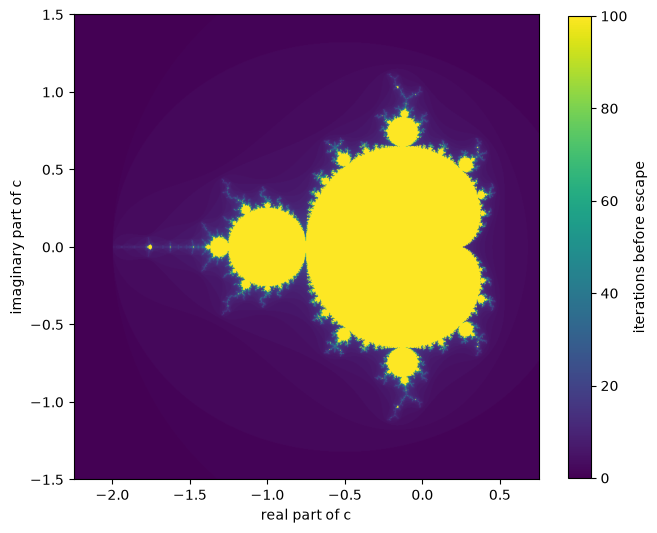

In [6]:
# the whole set, as a map with coordinates -- diagram first, artwork later
counts = escape_counts(center=(-0.75, 0.0), width=3.0, resolution=700)
plt.figure(figsize=(7.5, 7.5))
plt.imshow(counts, cmap="viridis", origin="lower",
           extent=[-2.25, 0.75, -1.5, 1.5])
plt.colorbar(label="iterations before escape", shrink=0.8)
plt.xlabel("real part of c")
plt.ylabel("imaginary part of c")
plt.show()

The bright interior is the set; the glowing fringe is where orbits take many iterations to decide, and all the visual drama lives on that fringe. The big disk on the left and the heart-shaped *cardioid* on the right meet in a pinch near $c = -0.75$: that pinch is the seahorse valley of today's showpiece.

**Try it.** Set `max_iter=20` in the cell above and rerun: the set gets fat and blurry, because slow-deciding pixels get misclassified as "inside". Deep zooms will need *more* iterations, not fewer; that trade-off is the price of every fractal image.

## From diagram to artwork: the colormap decides

Now switch off the axes and let the escape counts become an image. As in chapter 6, the colormap is not decoration, it *is* the artwork's palette; the structure is identical in all four panels below. One convention for the art renders: pixels inside the set are painted with count 0, so the set itself stays ink-black and the fringe does the talking.

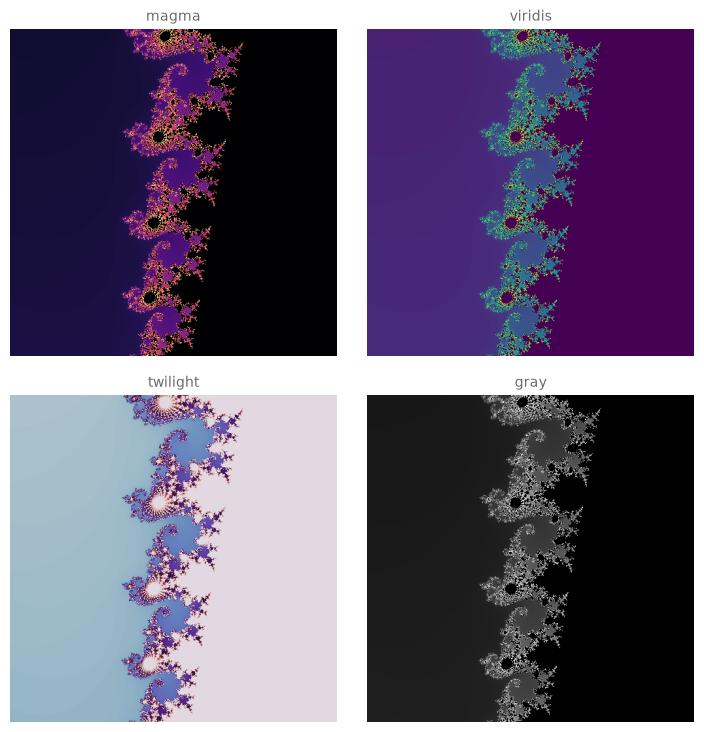

In [7]:
# one computation, four artworks: the colormap carries the aesthetics
def as_artwork(counts, max_iter):
    art = counts.copy()
    art[counts == max_iter] = 0          # interior: ink-black, not brightest
    return art

counts = escape_counts(center=(-0.745, 0.11), width=0.03,
                       resolution=500, max_iter=250)
fig, axes = plt.subplots(2, 2, figsize=(9, 9))
for ax, cmap in zip(axes.flat, ["magma", "viridis", "twilight", "gray"]):
    ax.imshow(as_artwork(counts, 250), cmap=cmap, origin="lower")
    ax.set_title(cmap, fontsize=10, color="#6B6B6B")
    ax.axis("off")
fig.subplots_adjust(wspace=0.05, hspace=0.12)
plt.show()

## Zooming: the detail never ends

A zoom is nothing but a smaller `width` around a chosen `center`, plus patience in `max_iter`. Here is a three-step descent into the seahorse valley, ending about five hundred times deeper than the full view. The repeating spirals-within-spirals are self-similarity made visible, though never *exact* repetition: every neighborhood of the boundary is subtly its own.

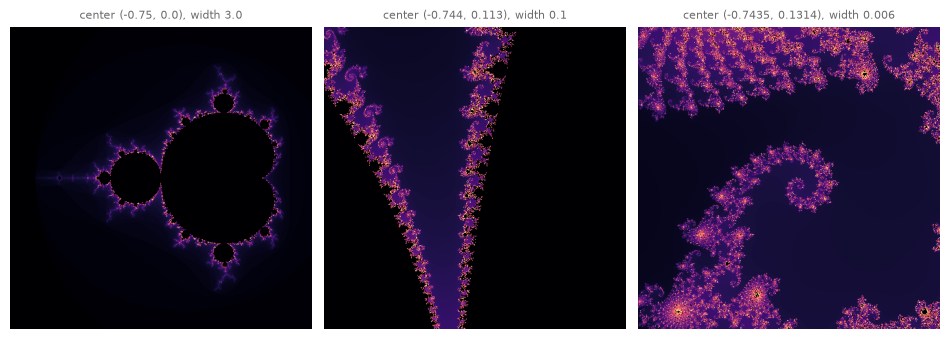

In [8]:
# three steps down into the seahorse valley, about 500x deeper in total
stops = [((-0.75, 0.0), 3.0, 100),
         ((-0.744, 0.113), 0.1, 250),
         ((-0.7435, 0.1314), 0.006, 500)]

fig, axes = plt.subplots(1, 3, figsize=(12, 4.4))
for ax, (center, width, max_iter) in zip(axes, stops):
    counts = escape_counts(center, width, resolution=440, max_iter=max_iter)
    ax.imshow(as_artwork(counts, max_iter), cmap="magma", origin="lower")
    ax.set_title(f"center {center}, width {width}", fontsize=8, color="#6B6B6B")
    ax.axis("off")
fig.subplots_adjust(wspace=0.04)
plt.show()

## Julia sets: the other side of the same formula

The formula $z_{\text{next}} = z^2 + c$ hides a second family of images. For the Mandelbrot set we varied $c$ per pixel and always started at $z = 0$. Do the opposite: **fix one $c$ for the whole image and vary the starting $z$ per pixel.** The result is the **Julia set** of that $c$ (after Gaston Julia, who studied these orbits around 1918, decades before anyone could draw them). Every point of the Mandelbrot set has its own Julia set; the Mandelbrot set acts as an atlas, and $c$ values near its boundary yield the most intricate Julias.

In [9]:
# the Julia set of a fixed c: same engine, roles of z and c exchanged
def julia_counts(c, width=3.2, resolution=500, max_iter=200):
    xs = np.linspace(-width / 2, width / 2, resolution)
    ys = np.linspace(-width / 2, width / 2, resolution)
    xx, yy = np.meshgrid(xs, ys)
    z = xx + 1j * yy                     # now the *starting points* vary...
    counts = np.zeros(z.shape)
    active = np.full(z.shape, True)
    for step in range(max_iter):
        z[active] = z[active] ** 2 + c   # ...and c is one constant for all
        active = active & (np.abs(z) <= 2)
        counts[active] += 1
    return counts

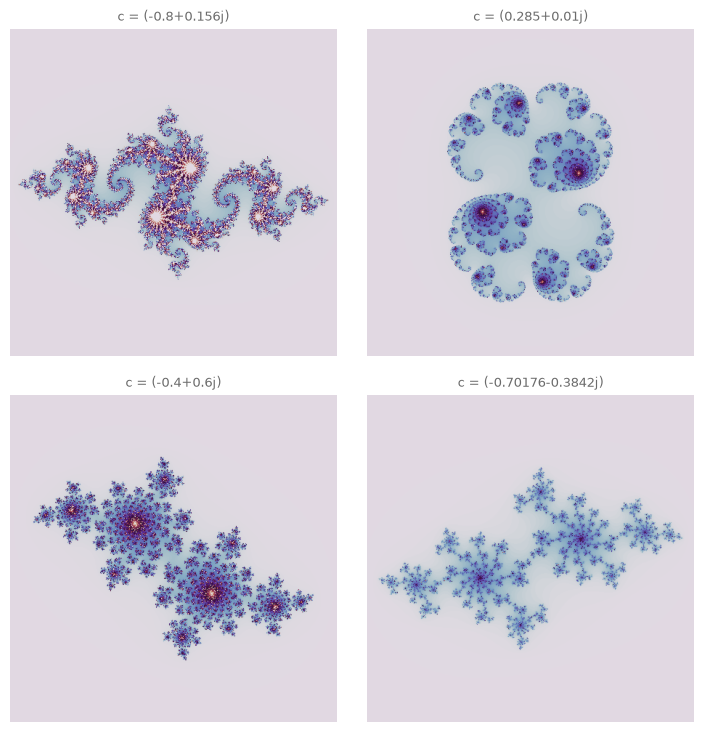

In [10]:
# four classic c values, four temperaments of the same formula
julia_cs = [-0.8 + 0.156j, 0.285 + 0.01j, -0.4 + 0.6j, -0.70176 - 0.3842j]
fig, axes = plt.subplots(2, 2, figsize=(9, 9))
for ax, c in zip(axes.flat, julia_cs):
    counts = julia_counts(c, resolution=450, max_iter=250)
    ax.imshow(as_artwork(counts, 250), cmap="twilight", origin="lower")
    ax.set_title(f"c = {c}", fontsize=9, color="#6B6B6B")
    ax.axis("off")
fig.subplots_adjust(wspace=0.05, hspace=0.12)
plt.show()

**Try it.** The sliders below steer $c$ through the complex plane (where widgets do not run, call `julia_explorer(-0.8, 0.156)` directly). Move slowly near the values above: a hundredth in $c$ can shatter the image, which is precisely what "sensitive dependence" means. Watch for the moment the set falls apart into dust: that happens exactly when $c$ leaves the Mandelbrot set.

In [11]:
# optional sliders -- everything they do, a direct call does too
def julia_explorer(c_real=-0.8, c_imag=0.156):
    counts = julia_counts(c_real + c_imag * 1j, resolution=350, max_iter=150)
    plt.figure(figsize=(5.5, 5.5))
    plt.imshow(as_artwork(counts, 150), cmap="twilight", origin="lower")
    plt.axis("off")
    plt.title(f"c = {c_real} {c_imag:+}i", fontsize=10, color="#6B6B6B")
    plt.show()

try:
    from ipywidgets import interact
    interact(julia_explorer, c_real=(-1.5, 0.5, 0.005), c_imag=(-1.0, 1.0, 0.005))
except ImportError:
    print("ipywidgets is not installed -- call julia_explorer(re, im) directly")

interactive(children=(FloatSlider(value=-0.8, description='c_real', max=0.5, min=-1.5, step=0.005), FloatSlide…

## Playground

The finished generator wraps computation and rendering. Three destinations are preset: the *elephant valley* on the set's east side, a spiral nebula deep in the seahorse region, and a miniature copy of the whole Mandelbrot set living on the antenna at the far west, self-similarity's star witness. Deeper targets need a larger `max_iter`; the printed pixel-iteration budget keeps you honest about what you are asking of the laptop.

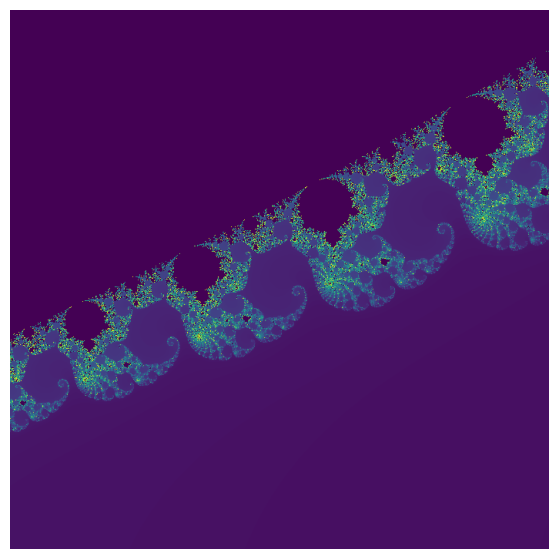

center (0.275, 0.007), width 0.01: up to 196 million pixel-iterations


In [11]:
# the finished generator: pick a place, a width, a palette
import sys
sys.path.append("..")
from agap.helpers import save_artwork

def mandelbrot_art(center, width, cmap="magma", resolution=700, max_iter=300):
    counts = escape_counts(center, width, resolution, max_iter)
    fig = plt.figure(figsize=(7, 7))
    plt.imshow(as_artwork(counts, max_iter), cmap=cmap, origin="lower")
    plt.axis("off")
    plt.show()
    budget = resolution * resolution * max_iter / 1e6
    print(f"center {center}, width {width}: "
          f"up to {budget:.0f} million pixel-iterations")
    return fig

art_1 = mandelbrot_art(center=(0.275, 0.007), width=0.01, cmap="viridis",
                       max_iter=400)

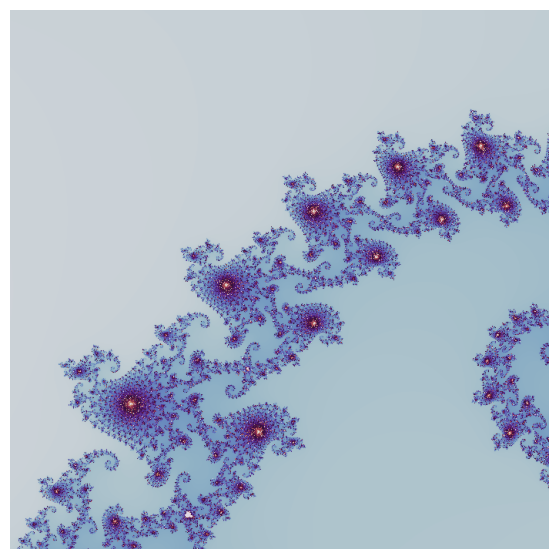

center (-0.7443, 0.1315), width 0.002: up to 294 million pixel-iterations


In [12]:
# temperament 2: a spiral in the seahorse region, in twilight
art_2 = mandelbrot_art(center=(-0.7443, 0.1315), width=0.002,
                       cmap="twilight", max_iter=600)

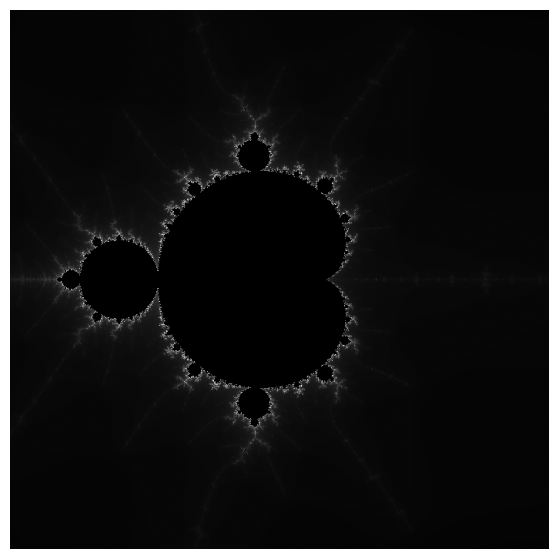

center (-1.755, 0.0), width 0.06: up to 196 million pixel-iterations


In [13]:
# temperament 3: a miniature Mandelbrot on the antenna, whole within the whole
art_3 = mandelbrot_art(center=(-1.755, 0.0), width=0.06, cmap="gray",
                       max_iter=400)

**Look and compare.** The three panels use three colormaps, and they read as three different artists. Which of them would you frame, and does your choice change if you imagine it two meters wide? Then look only at the miniature Mandelbrot: knowing its window is one fiftieth the width of the full set's, does that *knowledge* change the image's effect, the way knowing a painting's size changes a reproduction's?

## Export your artwork

Find your own coordinate (exercise a) or export one of the presets. Replace `yourname` and run; the print-quality PNG lands in `assets/outputs/`.

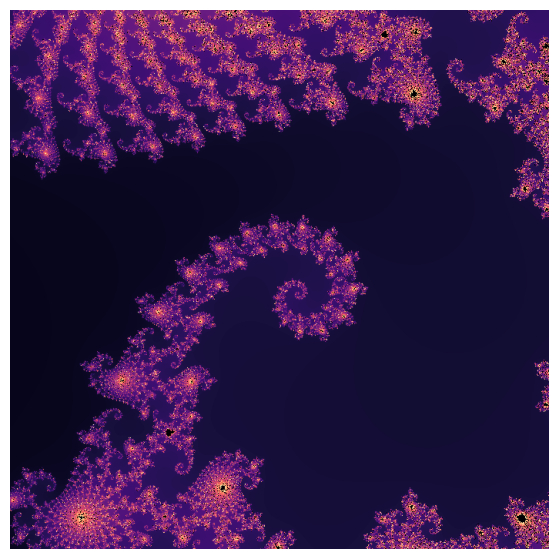

center (-0.7435, 0.1314), width 0.006: up to 245 million pixel-iterations


saved: assets/outputs/ch08_yourname.png


In [14]:
# save YOUR artwork: adjust center, width, palette, replace 'yourname', run
my_artwork = mandelbrot_art(center=(-0.7435, 0.1314), width=0.006,
                            cmap="magma", max_iter=500)
saved_path = save_artwork(my_artwork, "yourname", chapter=8)

## Exercises

**(a) Parameter exploration: claim a coordinate.** Zoom your way to a view nobody else in the room will find: pick a boundary region, halve `width` a few times, adjust `max_iter` upward as you go. Post your best `(center, width, max_iter, cmap)` to the course gallery *as text*: four numbers and a name are a complete, reproducible artwork, which is the purest statement of generative art this course can offer.

**(b) Code modification: smooth the bands.** The color bands in our renders are an artifact: escape counts are whole numbers, so neighboring pixels jump a full color step. The standard fix adds the *fraction* of a step at which the orbit crossed the escape radius:

$$n_{\text{smooth}} = n + 1 - \log_2\!\big(\log_2 |z_{\text{final}}|\big)$$

Modify `escape_counts` so it applies the formula to the escaped pixels and returns both the integer and the smoothed counts, then render the same view with both side by side.

<details><summary>Solution</summary>

```python
def escape_counts_smooth(center, width, resolution=600, max_iter=300):
    center_x, center_y = center
    xs = np.linspace(center_x - width / 2, center_x + width / 2, resolution)
    ys = np.linspace(center_y - width / 2, center_y + width / 2, resolution)
    xx, yy = np.meshgrid(xs, ys)
    c = xx + 1j * yy
    z = np.zeros_like(c)
    counts = np.zeros(c.shape)
    active = np.full(c.shape, True)
    for step in range(max_iter):
        z[active] = z[active] ** 2 + c[active]
        active = active & (np.abs(z) <= 2)
        counts[active] += 1
    smooth = counts.copy()
    escaped = counts < max_iter
    magnitude = np.abs(z)
    smooth[escaped] += 1 - np.log2(np.log2(magnitude[escaped]))
    return counts, smooth

counts, smooth = escape_counts_smooth((-0.7435, 0.1314), 0.006)
fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
for ax, image, label in [(axes[0], counts, "integer counts"),
                         (axes[1], smooth, "smooth counts")]:
    art = image.copy()
    art[counts == counts.max()] = 0
    ax.imshow(art, cmap="magma", origin="lower")
    ax.set_title(label, fontsize=10, color="#6B6B6B")
    ax.axis("off")
plt.show()
```

One wrinkle worth understanding: the formula needs $|z_{\text{final}}|$ *just after* escape, and since our loop freezes escaped pixels immediately, that is exactly what `z` still holds for them when the loop ends. The double logarithm turns "how far past the radius did it land" into "what fraction of a step was left", and the bands melt away.
</details>

**(c) Creative challenge: the burning ship.** Change the iteration to

$$z_{\text{next}} = \big(|\mathrm{Re}\,z| + i\,|\mathrm{Im}\,z|\big)^2 + c$$

(in code: `z = (abs(z.real) + 1j * abs(z.imag)) ** 2 + c`), and you have the *burning ship fractal*. Render the full set first (try center $(-0.5, -0.5)$, width 3), then hunt for the burning ship armada near center $(-1.755, -0.03)$, width 0.1. The ghostly ships are why this one-line variation has a fan community of its own. Flip the image with `origin="upper"` if your ships fly upside down, and consider what it means that one sign change rebuilds the whole world.

## Further reading

- Benoît Mandelbrot, *The Fractal Geometry of Nature* (1982): the manifesto, essayistic and readable in a way few mathematics books are.
- Richard Taylor, Adam Micolich and David Jonas, "Fractal analysis of Pollock's drip paintings", *Nature* 399 (1999), and Katherine Jones-Smith and Harsh Mathur, "Revisiting Pollock's drip paintings", *Nature* 444 (2006): read the two-page claim, then the two-page rebuttal, and form your own view; the pair is a masterclass in method criticism.
- Heinz-Otto Peitgen and Peter Richter, *The Beauty of Fractals* (1986): the book that carried these images into museums, with essays on the art question that remain fresh.
- Paul Bourke's [fractal pages](https://paulbourke.net/fractals/): decades of formulas, coordinates and renderings to raid for exercise (a).

---
### Appendix: regenerate the showpiece

This last cell (re)creates the image shown at the top of the notebook at print resolution; it takes on the order of half a minute. It runs automatically with *Restart & Run All*. For an even larger print, raise `resolution` (and be patient).

saved: assets/outputs/ch08_showpiece.png


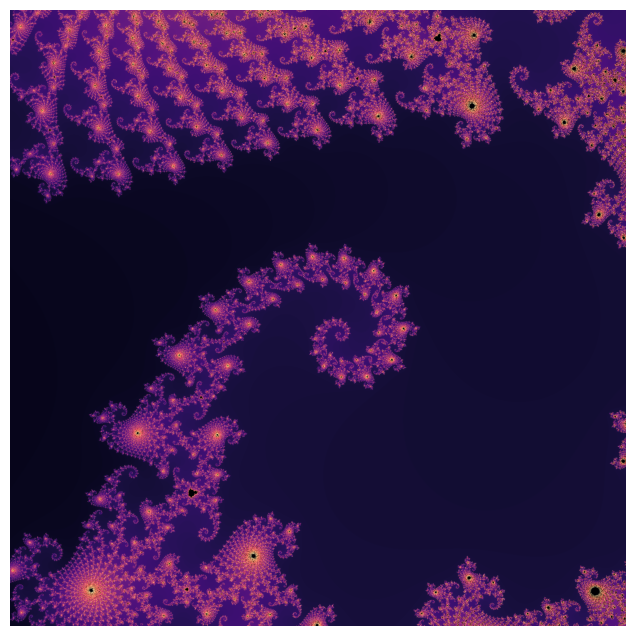

In [15]:
# regenerate this chapter's showpiece: seahorse valley at print resolution
from matplotlib import colormaps

counts = escape_counts(center=(-0.7435, 0.1314), width=0.006,
                       resolution=2048, max_iter=500)
art = as_artwork(counts, 500)
rgb = colormaps["magma"](art / art.max())[:, :, :3]   # counts to RGB pixels
showpiece = np.flipud(rgb)               # imsave writes row 0 at the top
saved_path = save_artwork(showpiece, "showpiece", chapter=8)
plt.figure(figsize=(8, 8))
plt.imshow(rgb, origin="lower")
plt.axis("off")
plt.show()